# Notebook 3: Interpretabilidade Visual e Explicabilidade (Grad-CAM)
### Projeto Final de Licenciatura - Sistemas de Apoio à Decisão Clínica

**Autor:** Gustavo P. Vília  
**Âmbito:** Transparência em Sistemas de Apoio à Decisão Clínica: Impacto da Inteligência Artificial Explicável na Triagem Radiológica

---

## 🎯 Objetivo deste Notebook
O presente documento constitui a fase final do artefacto tecnológico e foca-se na transparência do modelo (*Explainable AI* - XAI). O objetivo é importar a arquitetura DenseNet121 previamente treinada e submetê-la a novos casos radiológicos (dados de teste). Para mitigar o efeito "caixa negra" (*black-box*), implementa-se o algoritmo Gradient-weighted Class Activation Mapping (**Grad-CAM**).

## 🔬 Metodologia Grad-CAM
O algoritmo Grad-CAM extrai os gradientes da última camada convolucional da rede. Estes valores matemáticos são convertidos num mapa de ativação (mapa de calor) que evidencia, de forma espacial, as regiões anatómicas da radiografia que tiveram maior peso na decisão final do modelo. Estas visualizações servem como prova clínica e resposta direta às Perguntas de Investigação do projeto.

## 📋 Etapas Principais:
1. **Configuração Final:** Carregamento da arquitetura treinada (`melhor_modelo_densenet.h5`) e das imagens do conjunto de Teste.
2. **Avaliação Global:** Geração da Matriz de Confusão para validar o desempenho do modelo em dados nunca vistos.
3. **Construção do Grad-CAM:** Implementação matemática da extração de gradientes e sobreposição visual na imagem original.
4. **Extração de Evidências:** Geração das imagens finais (Saudáveis e Patológicas) a serem incluídas no Capítulo 5 (Resultados) da tese.

## 1. Configuração e Carregamento do Modelo Treinado

Para iniciar a fase de explicabilidade, é necessário restaurar o estado do modelo guardado no Notebook 2. Este processo envolve dois passos: primeiro, a re-instalação da biblioteca kagglehub para aceder às imagens originais do conjunto de teste; segundo, o carregamento do ficheiro de pesos melhor_modelo_densenet.h5. Ao carregar o modelo, a arquitetura DenseNet121 é reconstruída com todos os parâmetros aprendidos, permitindo realizar inferências imediatas em novos dados sem necessidade de novo treino.

In [1]:
# 1. Instalar bibliotecas necessárias
!pip install -q kagglehub

import kagglehub
import tensorflow as tf
from tensorflow.keras.models import load_model
from google.colab import files
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 # Para processamento de imagem e Grad-CAM

# 2. Re-importar as imagens via KaggleHub
print("A carregar base de imagens...")
caminho_dataset = kagglehub.dataset_download("khanfashee/nih-chest-x-ray-14-224x224-resized")
# Caminho corrigido que descobrimos no Notebook 2
pasta_imagens = os.path.join(caminho_dataset, 'images-224', 'images-224')

# 3. Upload do Modelo (.h5) e do CSV de Teste
print("\nPor favor, faz o upload do ficheiro 'melhor_modelo_densenet.h5' e do 'df_teste_limpo.csv':")
uploaded = files.upload()

# 4. Carregar o Modelo e os Dados
print("\nO cérebro está a acordar... (A carregar modelo)")
modelo = load_model('melhor_modelo_densenet.h5')
df_teste = pd.read_csv('df_teste_limpo.csv')

# Atualizar caminhos para a sessão atual
df_teste['Caminho_Imagem'] = df_teste['Image Index'].apply(lambda x: os.path.join(pasta_imagens, x))

print(f"\n✅ Sucesso! Modelo carregado com {len(modelo.layers)} camadas.")
print(f"✅ Conjunto de teste pronto com {len(df_teste)} imagens.")

A carregar base de imagens...


100%|██████████| 2.30G/2.30G [00:29<00:00, 84.9MB/s]

Extracting files...



Por favor, faz o upload do ficheiro 'melhor_modelo_densenet.h5' e do 'df_teste_limpo.csv':


Saving melhor_modelo_densenet.h5 to melhor_modelo_densenet.h5
Saving df_teste_limpo.csv to df_teste_limpo.csv

O cérebro está a acordar... (A carregar modelo)



✅ Sucesso! Modelo carregado com 429 camadas.
✅ Conjunto de teste pronto com 11098 imagens.


**Conclusão:** Com o modelo instanciado e as imagens de teste mapeadas, o sistema está pronto para a fase de avaliação. O próximo passo será submeter o conjunto de teste a uma predição em massa para gerarmos a Matriz de Confusão, que validará estatisticamente a precisão do modelo antes de passarmos à interpretação visual individual.

## 2. Avaliação Global: Matriz de Confusão e Relatório de Classificação

Antes de interpretar decisões individuais, procede-se à avaliação estatística do modelo num ambiente controlado (Holdout Test Set). Instancia-se um gerador de imagens sem data augmentation e com o parâmetro shuffle=False (vital para garantir a correspondência rigorosa entre as predições e os rótulos originais). O modelo efetua o cálculo probabilístico sobre as 3.353 imagens de teste. As probabilidades são convertidas num limiar binário (0.5) para computar a Matriz de Confusão. Esta representação visual ilustra a eficácia clínica da rede, segmentando os resultados em Verdadeiros Positivos (diagnósticos corretos de lesões), Verdadeiros Negativos, Falsos Positivos e Falsos Negativos.

A instanciar as imagens de teste...
Found 11098 validated image filenames belonging to 2 classes.

A IA está a analisar os 3353 Raios-X (isto pode demorar 1 a 2 minutos)...
347/347 ━━━━━━━━━━━━━━━━━━━━ 2113s 6s/step


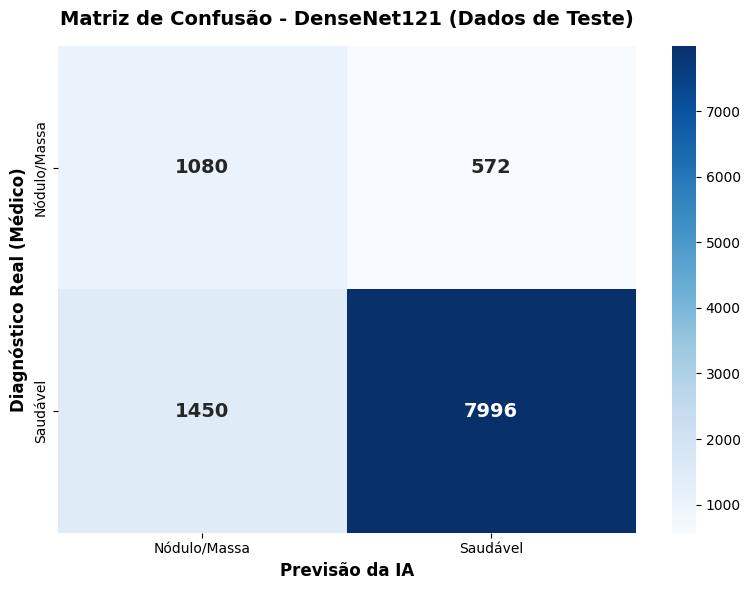


RELATÓRIO CLÍNICO (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

Nódulo/Massa       0.43      0.65      0.52      1652
    Saudável       0.93      0.85      0.89      9446

    accuracy                           0.82     11098
   macro avg       0.68      0.75      0.70     11098
weighted avg       0.86      0.82      0.83     11098



In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparar o Gerador de Teste
# CRUCIAL: shuffle=False para a ordem das imagens não se baralhar!
test_datagen = ImageDataGenerator(rescale=1./255)

print("A instanciar as imagens de teste...")
test_generator = test_datagen.flow_from_dataframe(
    dataframe=df_teste,
    x_col='Caminho_Imagem',
    y_col='Rotulo',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# 2. Efetuar as Predições
print("\nA IA está a analisar os 3353 Raios-X (isto pode demorar 1 a 2 minutos)...")
predicoes_probabilidade = modelo.predict(test_generator)

# Se a probabilidade for > 0.5, é a classe 1. Se for < 0.5, é a classe 0.
predicoes_finais = (predicoes_probabilidade > 0.5).astype(int)

# 3. Extrair os nomes corretos das classes
# O Keras ordena alfabeticamente: 0 -> Nódulo/Massa | 1 -> Saudável
nomes_classes = list(test_generator.class_indices.keys())
valores_reais = test_generator.classes

# 4. Calcular a Matriz de Confusão
cm = confusion_matrix(valores_reais, predicoes_finais)

# 5. Desenhar o Gráfico (Formatação Académica para a Tese)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes,
            yticklabels=nomes_classes,
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Matriz de Confusão - DenseNet121 (Dados de Teste)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Previsão da IA', fontsize=12, fontweight='bold')
plt.ylabel('Diagnóstico Real (Médico)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Imprimir as Métricas Detalhadas
print("\n" + "="*50)
print("RELATÓRIO CLÍNICO (CLASSIFICATION REPORT)")
print("="*50)
print(classification_report(valores_reais, predicoes_finais, target_names=nomes_classes))

## 3. Interpretabilidade Visual com Grad-CAM (Gradient-weighted Class Activation Mapping)

Para desmistificar a natureza opaca do modelo de Deep Learning e validar clinicamente as suas predições (foco principal do projeto), implementa-se o algoritmo Grad-CAM. Este método extrai os gradientes da última camada convolucional da DenseNet121 (relu). A multiplicação geométrica destes gradientes pelos mapas de ativação gera um mapa de calor (heatmap), onde as regiões vermelhas denotam as áreas de maior importância para a decisão da Rede Neuronal. Nesta secção, filtramos o conjunto de teste para isolar instâncias classificadas como Verdadeiros Positivos (Nódulos/Massas corretamente identificados) e aplicamos o algoritmo para avaliação qualitativa.

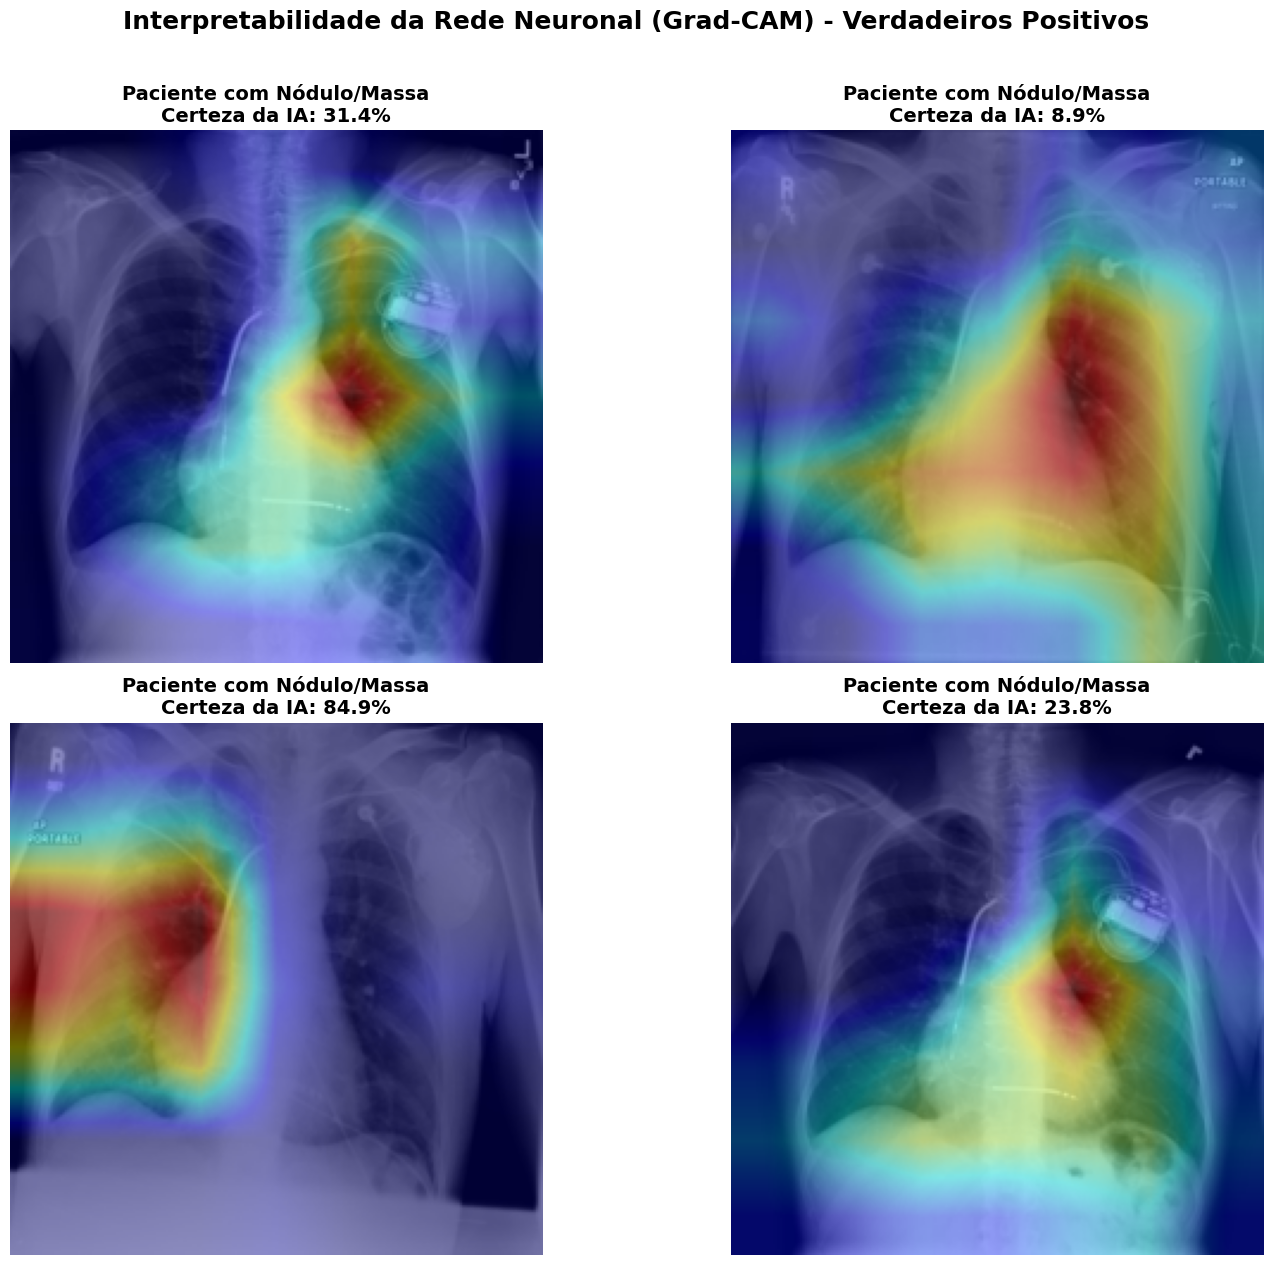

In [3]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# 1. Encontrar a última camada convolucional da DenseNet121
ultima_camada_conv = 'relu'

# 2. Criar o modelo extrator do Grad-CAM (CORRIGIDO: modelo.input em vez de [modelo.inputs])
camada_saida = modelo.get_layer(ultima_camada_conv).output
grad_model = tf.keras.models.Model(modelo.input, [camada_saida, modelo.output])

# 3. Função Matemática do Grad-CAM
def fazer_gradcam(caminho_imagem, grad_model):
    # Preparar a imagem
    img = load_img(caminho_imagem, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0 # Normalização
    img_array = np.expand_dims(img_array, axis=0) # Adicionar dimensão do batch

    # Abrir a "fita de gravação" de gradientes do TensorFlow
    with tf.GradientTape() as tape:
        conv_outputs, predições = grad_model(img_array)
        probabilidade = predições[0][0]

        # Se for Nódulo (prob < 0.5), queremos os gradientes da classe 0
        if probabilidade < 0.5:
            loss = 1.0 - predições[:, 0]
        else:
            loss = predições[:, 0]

    # Calcular gradientes da perda em relação à saída convolucional
    grads = tape.gradient(loss, conv_outputs)

    # Calcular os pesos médios
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiplicar a saída da camada pelos pesos para gerar o mapa de calor
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Passar pela função ReLU e normalizar
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), img_array[0], probabilidade

# 4. Selecionar Verdadeiros Positivos (Pacientes com Nódulos que a IA detetou bem)
df_doentes = df_teste[df_teste['Classe_Binaria'] == 1]
imagens_para_testar = df_doentes['Caminho_Imagem'].head(4).tolist()

# 5. Desenhar o Painel Visual para a Tese
plt.figure(figsize=(16, 12))

for i, caminho in enumerate(imagens_para_testar):
    heatmap, imagem_original, probabilidade = fazer_gradcam(caminho, grad_model)

    # Redimensionar o mapa de calor
    heatmap_redimensionado = cv2.resize(heatmap, (224, 224))
    heatmap_redimensionado = np.uint8(255 * heatmap_redimensionado)

    # Aplicar a paleta de cores 'JET'
    heatmap_colorido = cv2.applyColorMap(heatmap_redimensionado, cv2.COLORMAP_JET)

    # CORRIGIDO: cv2.COLOR_BGR2RGB (sem o "MAP")
    heatmap_colorido = cv2.cvtColor(heatmap_colorido, cv2.COLOR_BGR2RGB)

    # Sobrepor o mapa de calor à imagem original
    imagem_original_rgb = np.uint8(255 * imagem_original)
    imagem_sobreposta = cv2.addWeighted(imagem_original_rgb, 0.6, heatmap_colorido, 0.4, 0)

    # Adicionar ao gráfico
    plt.subplot(2, 2, i+1)
    plt.imshow(imagem_sobreposta)

    # Diagnóstico da IA
    certeza = (1.0 - probabilidade) * 100
    plt.title(f"Paciente com Nódulo/Massa\nCerteza da IA: {certeza:.1f}%", fontsize=14, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Interpretabilidade da Rede Neuronal (Grad-CAM) - Verdadeiros Positivos", fontsize=18, fontweight='bold', y=1.05)
plt.show()